# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
path = "/content/data_banknote_authentication.csv"

df = pd.read_csv(path)

# Show structure
print("Columns:", df.columns)
df.head()

Columns: Index(['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet',
       'Image_Entropy', 'Class'],
      dtype='object')


,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
df.columns = ["variance","skewness","curtosis","entropy","class"]
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
# Dataset information
df.info()

# Statistical summary
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


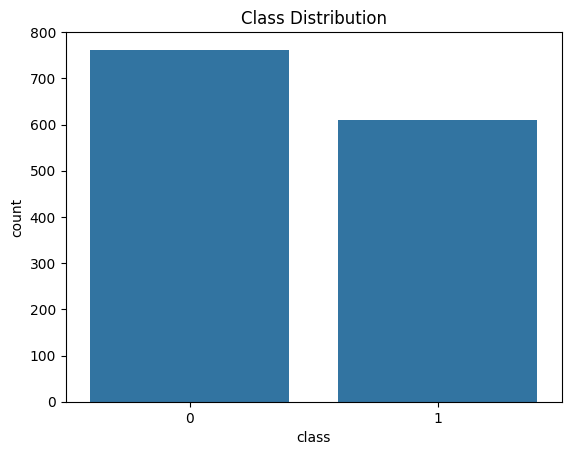

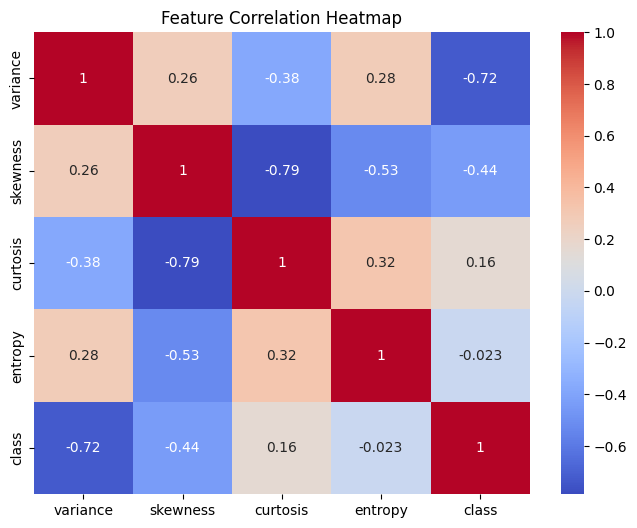

In [5]:
# Check class distribution
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
# Features and target
X = df.drop("class", axis=1)
y = df["class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1097, 4)
Testing shape: (275, 4)


In [7]:
# Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter grid
dt_params = {
    "max_depth": [None, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

# GridSearch
dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
dt_grid.fit(X_train, y_train)

# Best model
best_dt = dt_grid.best_estimator_

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


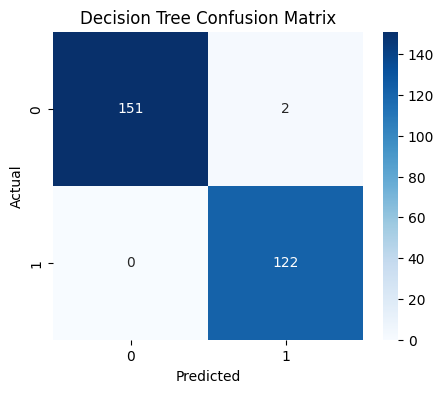

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [8]:
# Predictions
dt_pred = best_dt.predict(X_test)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, dt_pred))

In [9]:
# Random Forest model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "bootstrap": [True, False]
}

# GridSearch
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
rf_grid.fit(X_train, y_train)

# Best model
best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


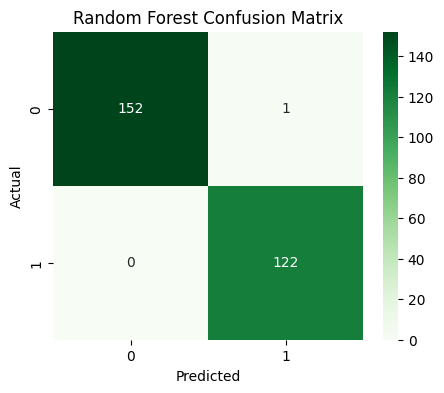

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       153
           1       0.99      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



In [10]:
# Predictions
rf_pred = best_rf.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))

In [11]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

if rf_accuracy > dt_accuracy:
    print("Random Forest performs better on this dataset.")
elif dt_accuracy > rf_accuracy:
    print("Decision Tree performs better on this dataset.")
else:
    print("Both models perform equally.")

Decision Tree Accuracy: 0.9927272727272727
Random Forest Accuracy: 0.9963636363636363
Random Forest performs better on this dataset.


as can be observed through the confusion metrices both have very very similar performance with high trues and low falses but the random forest is ever so slightly better than the decision tree this just proves one thing and that the data is very well groomed organized and cleaned ^^
